In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load — upload autompg.csv from Canvas first
df = pd.read_csv('autompg.csv').dropna()
print('Shape:', df.shape)   # should be (392, 9)
df.head()

Shape: (392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


## Q1 Identify the variables

- **Dependent variable (Y):** `mpg` — the value we are predicting (continuous → regression task)
- **Independent variable (X):** `displacement` — the single explanatory/input feature


In [3]:
X = df[['displacement']].values   # shape (392, 1) — 2D required by sklearn
y = df['mpg'].values               # shape (392,)  — 1D target

print(f'X (displacement): {X.shape}  range {X.min():.0f} – {X.max():.0f} cu.in.')
print(f'y (mpg):          {y.shape}  range {y.min():.1f} – {y.max():.1f} mpg')

X (displacement): (392, 1)  range 68 – 455 cu.in.
y (mpg):          (392,)  range 9.0 – 46.6 mpg


## Q2 Plot mpg vs. displacement

**Before running:** Based on domain knowledge (bigger engine → more fuel), should the trend be positive or negative?

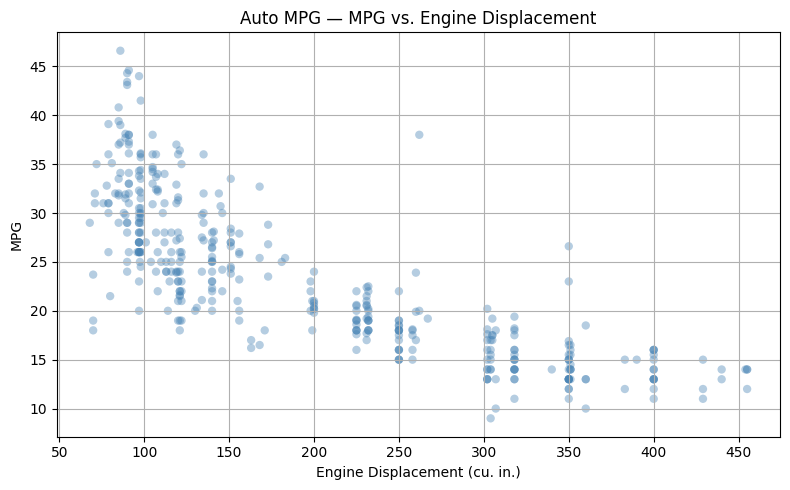

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.4, color='steelblue', edgecolors='none')
plt.xlabel('Engine Displacement (cu. in.)')
plt.ylabel('MPG')
plt.title('Auto MPG — MPG vs. Engine Displacement')
plt.grid(True)
plt.tight_layout()
plt.show()

## Q3 Fit the best-fit linear regression model

`LinearRegression()` solves the **Normal Equation** internally (via SVD/pseudoinverse).

**Before running:** Since the trend is negative, predict the sign of `coef_` (θ₁).

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

theta_0 = lin_reg.intercept_
theta_1 = lin_reg.coef_[0]

print(f'θ₀ (intercept):         {theta_0:.4f}')
print(f'θ₁ (displacement coef): {theta_1:.4f}')

θ₀ (intercept):         35.1206
θ₁ (displacement coef): -0.0601


## Q4  Overlay best-fit line over the scatter plot

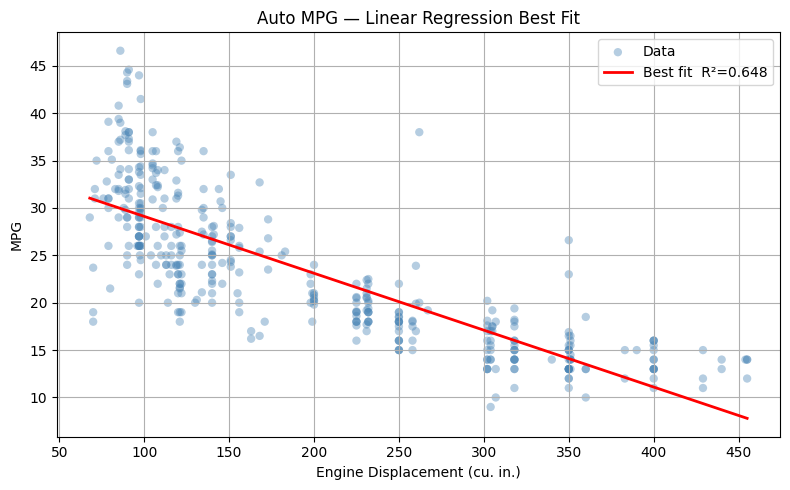

In [9]:
X_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_line = lin_reg.predict(X_line)
r2 = lin_reg.score(X, y)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.4, color='steelblue', edgecolors='none', label='Data')
plt.plot(X_line, y_line, 'r-', linewidth=2, label=f'Best fit  R²={r2:.3f}')
plt.xlabel('Engine Displacement (cu. in.)')
plt.ylabel('MPG')
plt.title('Auto MPG — Linear Regression Best Fit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Q5 Prediction equation

Hint from the slide: assemble the equation from `intercept_` and `coef_`.

In [10]:
print('Prediction equation:')
print(f'  mpg = {theta_0:.4f} + ({theta_1:.4f}) × displacement')
print(f'  mpg = {theta_0:.2f} − {abs(theta_1):.4f} × displacement')
print()
print(f'θ₁ = {theta_1:.4f}: each +1 cu.in. of displacement reduces mpg by {abs(theta_1):.4f}')

Prediction equation:
  mpg = 35.1206 + (-0.0601) × displacement
  mpg = 35.12 − 0.0601 × displacement

θ₁ = -0.0601: each +1 cu.in. of displacement reduces mpg by 0.0601


## Q6 Predictions

**Before running — think it through:**
- Training data displacement range: **68 – 455 cu.in.**
- `250` is inside that range → **interpolation** → trustworthy
- `600` is outside that range → **extrapolation** → what happens when a line keeps going past the data?

In [11]:
pred_250 = lin_reg.predict([[250]])[0]
pred_600 = lin_reg.predict([[600]])[0]

print(f'Predicted mpg @ displacement=250: {pred_250:.2f} mpg  ← interpolation (within training range)')
print(f'Predicted mpg @ displacement=600: {pred_600:.2f} mpg  ← extrapolation (max training = {X.max():.0f})')
print()
print('A negative mpg is physically impossible.')
print('This is the danger of extrapolation — the model has no data to anchor it.')

Predicted mpg @ displacement=250: 20.11 mpg  ← interpolation (within training range)
Predicted mpg @ displacement=600: -0.91 mpg  ← extrapolation (max training = 455)

A negative mpg is physically impossible.
This is the danger of extrapolation — the model has no data to anchor it.


## Summary of Results

| Item | Value |
|---|---|
| Dependent variable | `mpg` |
| Independent variable | `displacement` |
| θ₀ (intercept) | 35.1206 |
| θ₁ (slope) | −0.0601 |
| R² | 0.6482 |
| Prediction @ displacement=250 | **20.11 mpg**  |
| Prediction @ displacement=600 | **−0.91 mpg**  (extrapolation) |

**Key takeaway:** R² ≈ 0.65 means displacement explains ~65% of mpg variation — decent for one feature, but clearly not the whole story.

In [15]:
from sklearn.linear_model import SGDRegressor

# Instructor's exact snippet — on RAW (unscaled) displacement
sgd_raw = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, random_state=42)
sgd_raw.fit(X, y.ravel())

print("RAW (unscaled) SGD:")
print("  intercept:", sgd_raw.intercept_)
print("  coef:", sgd_raw.coef_)
print("  pred@250:", sgd_raw.predict([[250]]))
print("  pred@600:", sgd_raw.predict([[600]]))
print("\n→ Notice these are absurd numbers — SGD diverged because displacement isn't scaled.")

RAW (unscaled) SGD:
  intercept: [1.96115012e+10]
  coef: [1.5909823e+11]
  pred@250: [3.9794169e+13]
  pred@600: [9.54785494e+13]

→ Notice these are absurd numbers — SGD diverged because displacement isn't scaled.


Fix it with Standard Scalar

In [13]:
from sklearn.preprocessing import StandardScaler

# Scale the feature so SGD can converge
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sgd = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, random_state=42)
sgd.fit(X_scaled, y.ravel())

# IMPORTANT: scale the new inputs the same way before predicting
pred_250 = sgd.predict(scaler.transform([[250]]))[0]
pred_600 = sgd.predict(scaler.transform([[600]]))[0]

print("SCALED SGD:")
print(f"  pred@250: {pred_250:.2f} mpg")
print(f"  pred@600: {pred_600:.2f} mpg")
print(f"\nAnalytical was: 20.11 and -0.91 — now they match!")

SCALED SGD:
  pred@250: 20.12 mpg
  pred@600: -0.80 mpg

Analytical was: 20.11 and -0.91 — now they match!


In [14]:
print(f"{'eta0':>8} {'max_iter':>10} {'pred@250':>10} {'pred@600':>10}")
for eta0 in [0.001, 0.01, 0.1]:
    for max_iter in [100, 1000, 5000]:
        m = SGDRegressor(max_iter=max_iter, tol=1e-5, penalty=None,
                         eta0=eta0, random_state=42)
        m.fit(X_scaled, y.ravel())
        p250 = m.predict(scaler.transform([[250]]))[0]
        p600 = m.predict(scaler.transform([[600]]))[0]
        print(f"{eta0:>8} {max_iter:>10} {p250:>10.2f} {p600:>10.2f}")

    eta0   max_iter   pred@250   pred@600
   0.001        100      19.62      -0.89
   0.001       1000      20.09      -0.91
   0.001       5000      20.09      -0.91
    0.01        100      20.12      -0.80
    0.01       1000      20.12      -0.80
    0.01       5000      20.12      -0.80
     0.1        100      19.95       0.37
     0.1       1000      19.95       0.37
     0.1       5000      19.95       0.37


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


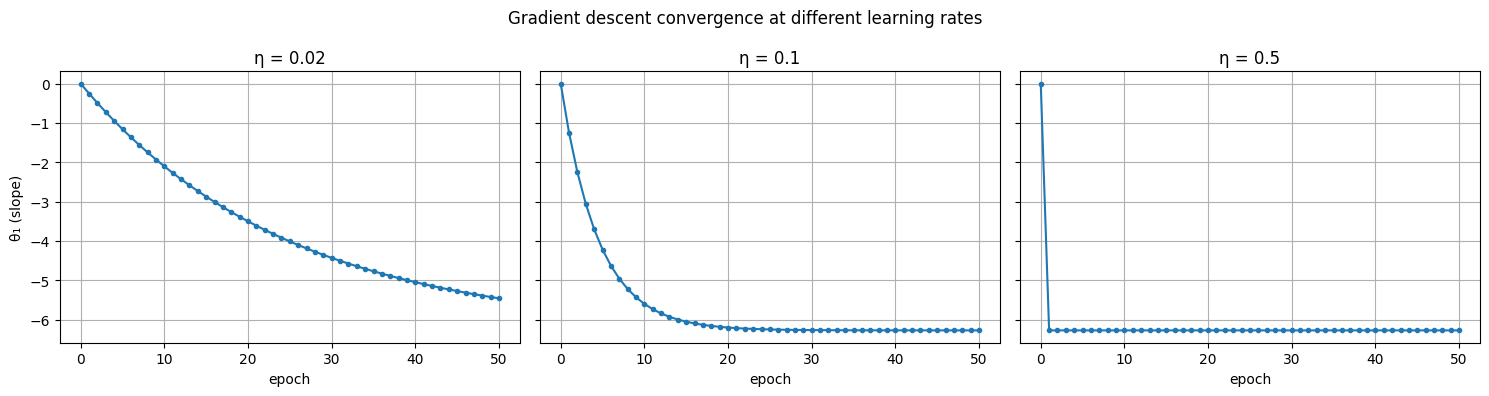

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Scale so gradient descent behaves (same lesson as the SGD classwork)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
Xb = np.c_[np.ones(len(Xs)), Xs]   # add x0=1 column for the bias term
m = len(Xb)

def run_gd(eta, n_epochs=50):
    theta = np.zeros((2, 1))        # start at [0, 0]
    path = [theta.flatten().copy()]
    yv = y.reshape(-1, 1)
    for _ in range(n_epochs):
        gradients = 2/m * Xb.T @ (Xb @ theta - yv)
        theta = theta - eta * gradients
        path.append(theta.flatten().copy())
    return np.array(path)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, eta in zip(axes, [0.02, 0.1, 0.5]):
    path = run_gd(eta)
    ax.plot(path[:, 1], marker='.')          # watch the slope parameter converge
    ax.set_title(f"η = {eta}")
    ax.set_xlabel("epoch")
    ax.grid(True)
axes[0].set_ylabel("θ₁ (slope)")
plt.suptitle("Gradient descent convergence at different learning rates")
plt.tight_layout()
plt.show()

## Summary — SGD Classwork (Slide 40)

**Goal:** Model `mpg` from engine `displacement` using Stochastic Gradient Descent,
then compare to the analytical (Normal Equation) solution.

### Key finding: feature scaling is required
Running `SGDRegressor` on raw `displacement` (range 68–455) **diverges** — the
weights explode to ~10¹⁰ and predictions are meaningless. This happens because
the large feature values produce huge gradient steps that overshoot the minimum.
Applying `StandardScaler` to the feature fixes this, and SGD then converges to
essentially the same solution as the Normal Equation.

### Predictions (after scaling)

| displacement | SGD prediction | Analytical (Normal Eq.) |
|---|---|---|
| 250 | ~20.1 mpg | 20.11 mpg |
| 600 | ~−0.8 mpg | −0.91 mpg |

Note: `displacement = 600` is **extrapolation** (max in training data = 455).
The negative mpg is physically impossible and shows the model cannot be trusted
outside its training range.

### Q: Are predictions sensitive to the hyperparameters (max_iter, eta0)?
**Yes.**
- **Without scaling:** the choice of `eta0` is the difference between convergence
  and total divergence — extreme sensitivity.
- **With scaling:** too small an `eta0` or too few iterations (`max_iter`) leaves
  the model short of the minimum (under-converged). Once `eta0` is reasonable and
  `max_iter` is large enough, the predictions stabilize and stop changing.

### Q: How do SGD predictions compare to the analytical solution?
After scaling, SGD lands within ~0.1 mpg of the Normal Equation result. This is
expected: both methods minimize the **same** least-squares cost function. The
Normal Equation solves it in one step (analytically); SGD reaches the same minimum
iteratively. They converge to the same answer because the MSE cost function is
convex (a single global minimum).